In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

Can a CNN distingish between Class 0 (low spread of the noise) and Class 1 (higher spread)?

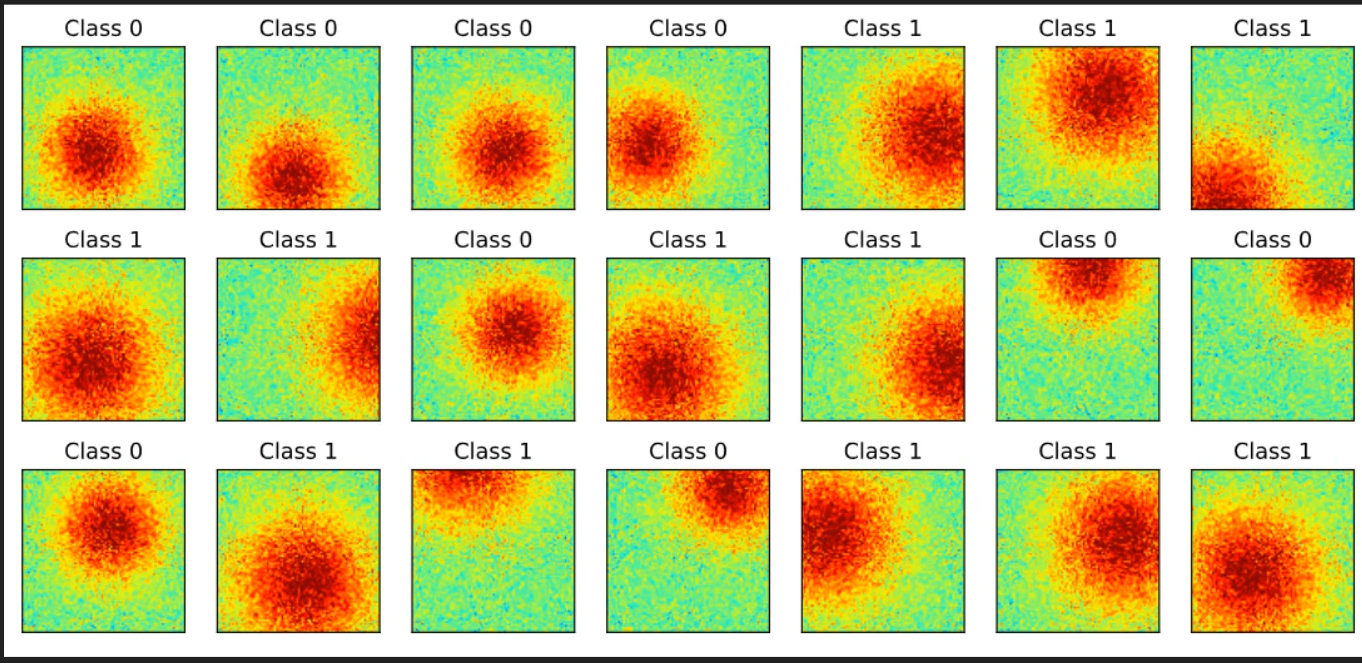

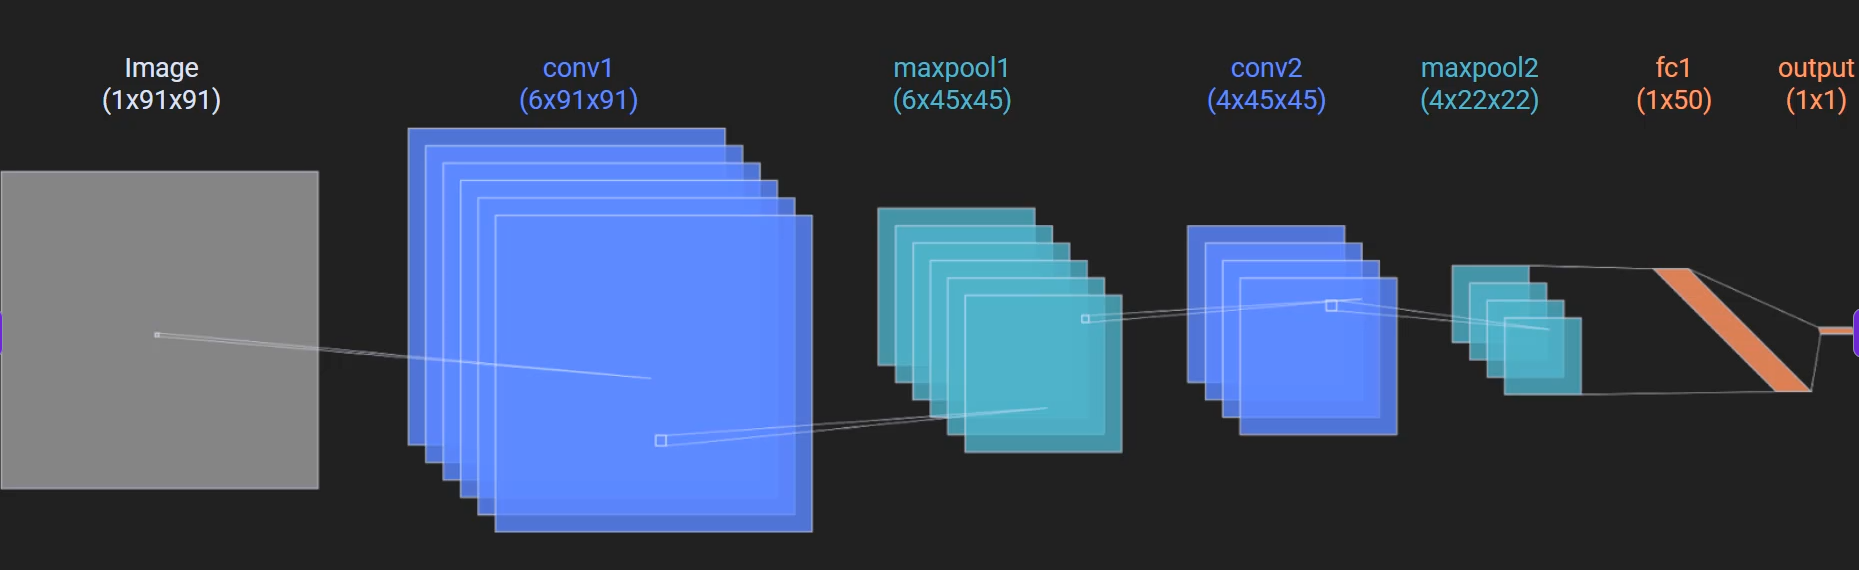

While "Standard CNNs" usually increase depth to capture more complex abstractions, this specific design prioritizes efficiency and dimensionality reduction to prevent the model from becoming too "heavy" for a very simple 1×1 output task.

In [3]:
# create a guassian blur with different widths
n_per_class = 1000 # number of samples per class (total samples will be 2*1000 = 2000)
img_size = 91


x = np.linspace(-4, 4, img_size)
X, Y = np.meshgrid(x, x)

class_widths = [1.8, 2.4] # class 0 will have a width of 1.8 and class 1 will have a width of 2.4

images = torch.zeros((2*n_per_class, 1, img_size, img_size)) # create a tensor to hold the images
labels = torch.zeros(2*n_per_class, dtype=torch.long) # create a tensor to hold the labels

for i in range(2): # for each class
    for j in range(n_per_class): # for each sample in the class
        width = class_widths[i] # get the width for the class
        center = 2*np.random.randn(2) # randomly shift the center of the gaussian blur
        gauss = np.exp(-((X - center[0])**2 + (Y - center[1])**2) / (2 * width**2)) # create a gaussian blur with the given width and center
        gauss = gauss + np.random.randn(img_size, img_size) * 0.2 # add some noise to the image

        images[i*n_per_class + j] = torch.tensor(gauss).view(1, img_size, img_size) # store the image in the tensor
        labels[i*n_per_class + j] = i # store the label (0 for class 0 and 1 for class 1)

labels = labels.view(-1, 1) # reshape labels to be a column vector

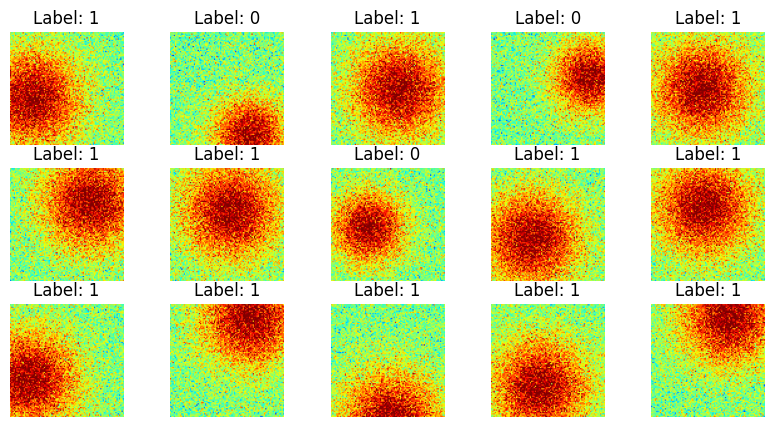

In [4]:
# visualize some images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(ax.flatten()):
    random_pic = np.random.randint(0, 2*n_per_class) # randomly select an image from the dataset
    ax.imshow(images[random_pic].squeeze(), cmap='jet', vmin=-1, vmax=1)
    ax.set_title(f'Label: {labels[random_pic].item()}')
    ax.axis('off')

In [5]:
# create train and test dataloaders
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [6]:
class GAUS_NET(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1), # output: (6, 91, 91)
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2), # output: (6, 45, 45)

            nn.Conv2d(in_channels=6, out_channels=4, kernel_size=3, stride=1, padding=1), # output: (4, 45, 45)
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2), # output: (4, 22, 22)

            nn.Flatten(), # output: (4*22*22) = (1936)
            nn.Linear(in_features=1936, out_features=50),
            nn.ReLU(),
            nn.Linear(in_features=50, out_features=1)
        )

    def forward(self, x):
        return self.encoder(x)
    
model = GAUS_NET()
summary(model, input_size=(1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         AvgPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         AvgPool2d-6            [-1, 4, 22, 22]               0
           Flatten-7                 [-1, 1936]               0
            Linear-8                   [-1, 50]          96,850
              ReLU-9                   [-1, 50]               0
           Linear-10                    [-1, 1]              51
Total params: 97,181
Trainable params: 97,181
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.00
Params size (MB): 0.37
Estimated Tot

In [7]:
# test the model with a batch of data
# we have to ensure that the input and output shapes are correct before we start training the model, otherwise we might run into errors during training
model = GAUS_NET()
images, labels = next(iter(train_dataloader))
outputs = model(images)
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Output shape: {outputs.shape}")
loss_fn = nn.BCEWithLogitsLoss()
print(f"Loss: {loss_fn(outputs, labels.float())}") # labels need to be float for BCEWithLogitsLoss

Images shape: torch.Size([32, 1, 91, 91])
Labels shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])
Loss: 0.6948379278182983


In [8]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer):
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y.float())
        train_loss += loss.item()

        # Match shapes before comparison to avoid broadcasting bugs
        predicted = (y_pred > 0).long().view(-1) # long transform into an integer tensor and view to match the shape of the target
        target = y.long().view(-1)
        train_accuracy += (predicted == target).float().mean().item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int = 5):

    train_losses_epochs = []
    test_losses_epochs = []
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        train_losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        test_loss = 0.0

        with torch.no_grad():
            for X, y in test_dataloader:
                y_pred = model(X)
                loss = loss_fn(y_pred, y.float())
                test_loss += loss.item()

                predicted = (y_pred > 0).long().view(-1)
                target = y.long().view(-1)
                test_accuracy += (predicted == target).float().mean().item()

        avg_test_loss = test_loss / len(test_dataloader)
        avg_test_acc = test_accuracy / len(test_dataloader)
        test_losses_epochs.append(avg_test_loss)
        test_accuracy_epochs.append(avg_test_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Train Accuracy: {avg_train_acc*100:.2f}%, "
            f"Test Accuracy: {avg_test_acc*100:.2f}%"
        )

    return train_losses_epochs, test_losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [9]:
model = GAUS_NET()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 12
train_losses, test_losses, train_accuracy, test_accuracy = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch [1/12], Train Loss: 0.5262, Train Accuracy: 74.38%, Test Accuracy: 88.94%
Epoch [2/12], Train Loss: 0.2075, Train Accuracy: 95.69%, Test Accuracy: 95.67%
Epoch [3/12], Train Loss: 0.1222, Train Accuracy: 96.62%, Test Accuracy: 97.12%
Epoch [4/12], Train Loss: 0.0993, Train Accuracy: 97.12%, Test Accuracy: 97.84%
Epoch [5/12], Train Loss: 0.0859, Train Accuracy: 97.12%, Test Accuracy: 97.84%
Epoch [6/12], Train Loss: 0.0716, Train Accuracy: 97.75%, Test Accuracy: 97.84%
Epoch [7/12], Train Loss: 0.0630, Train Accuracy: 98.00%, Test Accuracy: 97.84%
Epoch [8/12], Train Loss: 0.0621, Train Accuracy: 97.94%, Test Accuracy: 97.84%
Epoch [9/12], Train Loss: 0.0547, Train Accuracy: 98.06%, Test Accuracy: 98.08%
Epoch [10/12], Train Loss: 0.0528, Train Accuracy: 98.25%, Test Accuracy: 97.84%
Epoch [11/12], Train Loss: 0.0492, Train Accuracy: 98.31%, Test Accuracy: 97.84%
Epoch [12/12], Train Loss: 0.0480, Train Accuracy: 98.44%, Test Accuracy: 97.84%


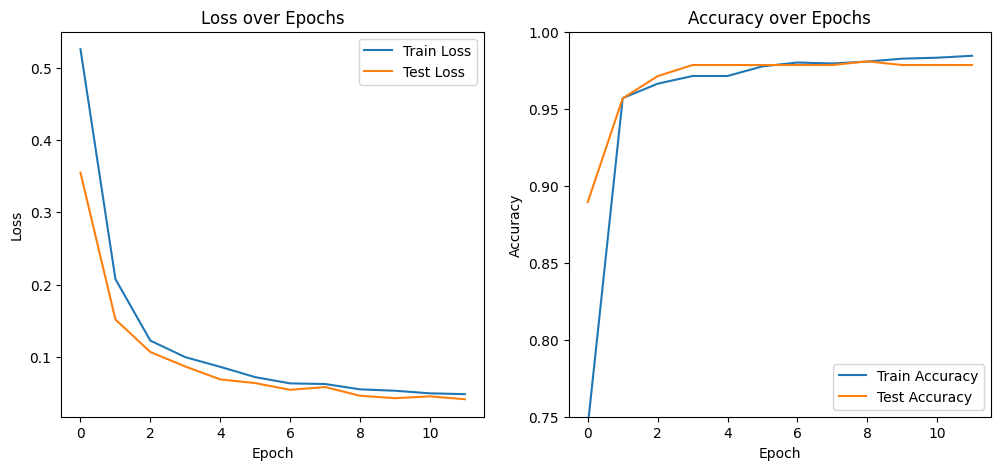

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses, label='Train Loss')
ax[0].plot(test_losses, label='Test Loss')
ax[0].set_title('Loss over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(train_accuracy, label='Train Accuracy')
ax[1].plot(test_accuracy, label='Test Accuracy')
ax[1].set_title('Accuracy over Epochs')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.75, 1) # set y-axis limits to [0, 1] for better visualization of accuracy
ax[1].legend()

# the accuracy over epoch seems a little bit unstable, we could try to increase the number of epochs or decrease the learning
# rate to see if it stabilizes, but for now we will leave it as is since we are just testing the model and not trying to achieve 
# the best possible performance. 

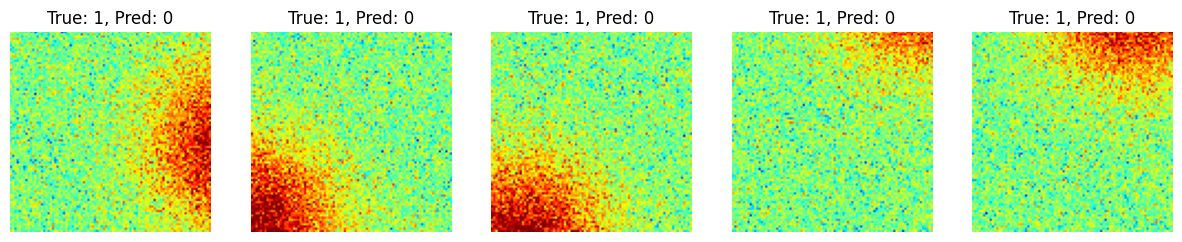

In [11]:
# plot examples where the model made wrong predictions
model.eval()

num_wrong_examples = 5

with torch.no_grad():
    wrong_examples = []
    for X, y in test_dataloader:
        y_pred = model(X)
        predicted = (y_pred > 0).long().view(-1)
        target = y.long().view(-1)
        for i in range(len(predicted)):
            if predicted[i] != target[i]:
                wrong_examples.append((X[i], target[i], predicted[i]))
            if len(wrong_examples) >= num_wrong_examples:
                break
        if len(wrong_examples) >= num_wrong_examples:
            break

fig, ax = plt.subplots(1, num_wrong_examples, figsize=(15, 5))
for i in range(num_wrong_examples):
    ax[i].imshow(wrong_examples[i][0].squeeze(), cmap='jet', vmin=-1, vmax=1)
    ax[i].set_title(f'True: {wrong_examples[i][1].item()}, Pred: {wrong_examples[i][2].item()}')
    ax[i].axis('off')

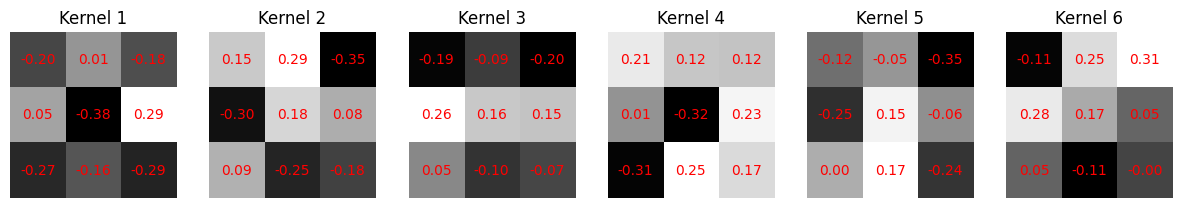

In [12]:
# show the kernels of the first convolutional layer including a the value of each cell in the kernel
first_conv_layer = model.encoder[0] # get the first convolutional layer
kernels = first_conv_layer.weight.data.cpu().numpy() # get the weights of the first convolutional layer
fig, ax = plt.subplots(1, kernels.shape[0], figsize=(15, 5))
for i in range(kernels.shape[0]):
    ax[i].imshow(kernels[i, 0], cmap='gray')
    for (j, k), val in np.ndenumerate(kernels[i, 0]):
        ax[i].text(k, j, f'{val:.2f}', ha='center', va='center', color='red')
    ax[i].set_title(f'Kernel {i+1}')
    ax[i].axis('off')

# the weights change during learning but are fixed after that. They are independent of new feature data.

# the activation of the layers in each channel (feature map) are not learned, they are calculated based on 
# the input data and the weights of the kernels. The activation of each layer is a result of the convolution
# operation between the input data and the kernels, followed by the application of an activation function (like ReLU).

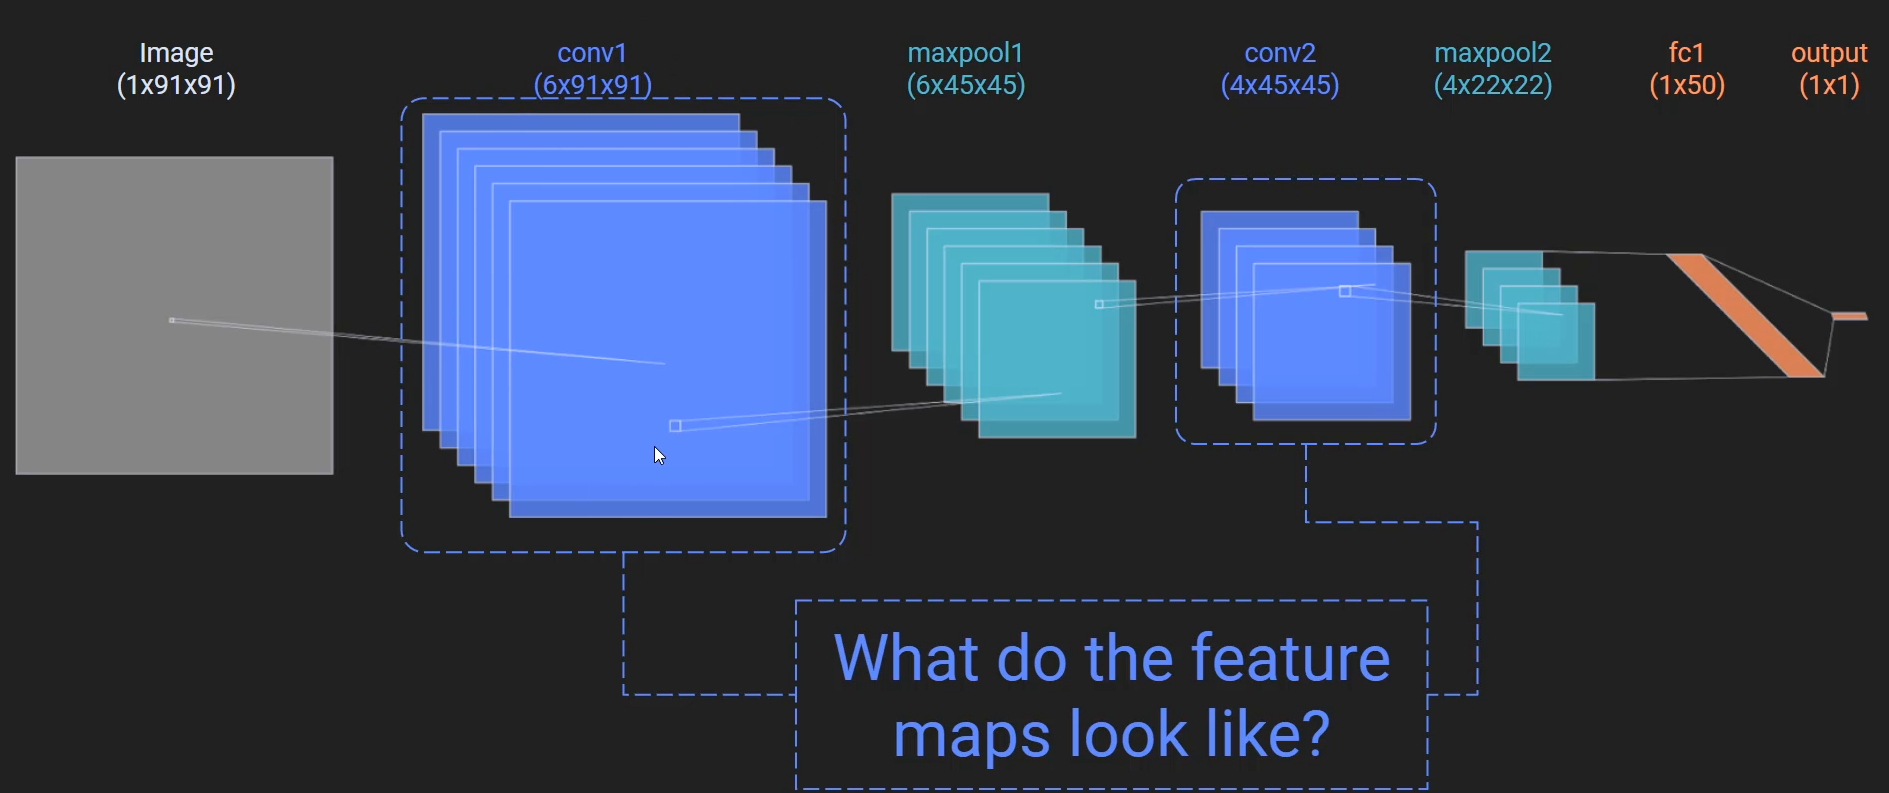

In [38]:
model.encoder[0:2]

Sequential(
  (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
)

In [39]:
model.encoder[0:5]

Sequential(
  (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (3): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
)

torch.Size([1, 91, 91])


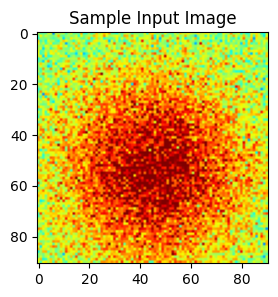

torch.Size([1, 6, 91, 91])


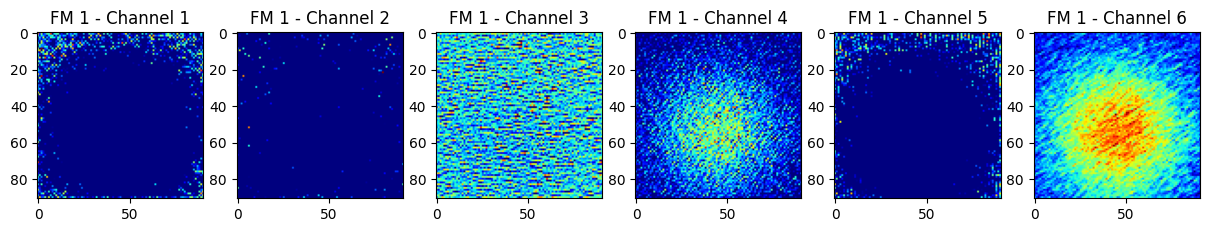

torch.Size([1, 4, 45, 45])


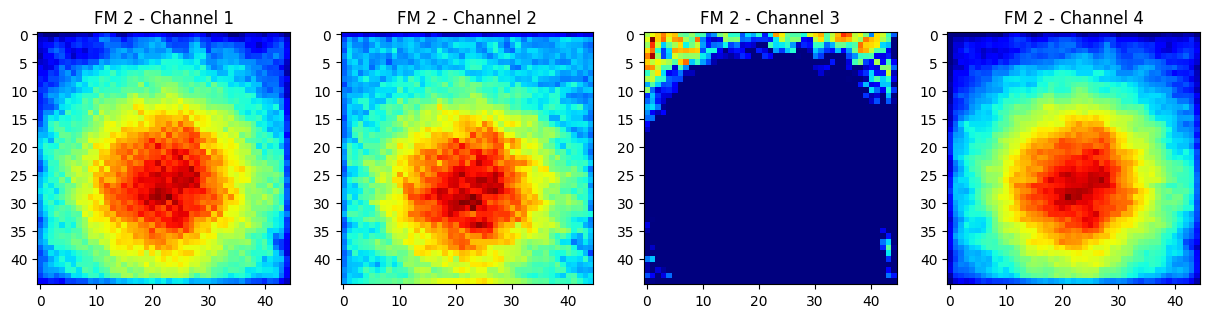

In [52]:
# what do the feature maps look like after the first two convolutional layers?
# these feature maps are not learned, they are calculated based on the input data 
# and the weights of the kernels. Therefore each image will have different feature maps.

model.eval()
with torch.no_grad():
    sample_image = images[0].unsqueeze(0) # take a sample image and add a batch dimension
    feature_maps1 = model.encoder[0:2](sample_image) # get the output of the first convolutional layer (before pooling)
    feature_maps2 = model.encoder[0:5](sample_image) # get the output of the first two convolutional layers (before flattening)

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
print(images[0].shape) # should be (1, 91, 91)
ax.imshow(sample_image.squeeze(), cmap='jet', vmin=-1, vmax=1)
ax.set_title('Sample Input Image')
plt.show()

fig, ax = plt.subplots(1, 6, figsize=(15, 5))
print(feature_maps1.shape) # should be (1, 6, 91, 91) since we have 6 output channels in the first convolutional layer
for i in range(feature_maps1.shape[1]):
    ax[i].imshow(feature_maps1[0, i].cpu(), cmap='jet', vmin=0) # set vmin and vmax to better visualize the activations
    ax[i].set_title(f'FM 1 - Channel {i+1}')
plt.show()

fig, ax = plt.subplots(1, 4, figsize=(15, 5))
print(feature_maps2.shape) # should be (1, 4, 45, 45) since we have 4 output channels in the second convolutional layer 
for i in range(feature_maps2.shape[1]):
    ax[i].imshow(feature_maps2[0, i].cpu(), cmap='jet', vmin=0) # set vmin and vmax to better visualize the activations
    ax[i].set_title(f'FM 2 - Channel {i+1}')
plt.show()

Some feature maps could resemble each others like FM1-C2 and FM1-C5 or FM1-C4 and FM1-C6

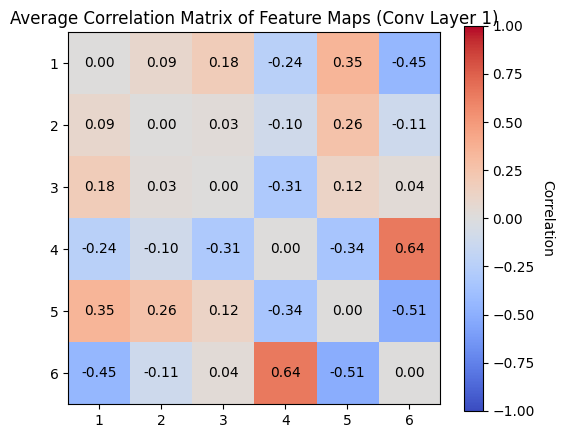

In [55]:
# compute the average correlation between the feature maps of the first convolutional layer for all the images
model.eval()
with torch.no_grad():
    correlation_matrices = []
    for i in range(len(images)):
        sample_image = images[i].unsqueeze(0) # add batch dimension
        feature_maps = model.encoder[0:2](sample_image) # get the output of the first convolutional layer
        correlation_matrix = np.zeros((feature_maps.shape[1], feature_maps.shape[1]))
        for j in range(feature_maps.shape[1]):
            for k in range(j+1, feature_maps.shape[1]):
                fm1 = feature_maps[0, j].cpu().numpy().flatten()
                fm2 = feature_maps[0, k].cpu().numpy().flatten()
                correlation = np.corrcoef(fm1, fm2)[0, 1]
                correlation_matrix[j, k] = correlation
                correlation_matrix[k, j] = correlation
        correlation_matrices.append(correlation_matrix)

    average_correlation_matrix = np.mean(correlation_matrices, axis=0)

    
# plot the average correlation matrix with the values of the correlations in each cell
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(average_correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Average Correlation Matrix of Feature Maps (Conv Layer 1)')
# add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Correlation', rotation=-90, va="bottom")
# add text annotations
for i in range(average_correlation_matrix.shape[0]):
    for j in range(average_correlation_matrix.shape[1]):
        text = ax.text(j, i, f'{average_correlation_matrix[i, j]:.2f}', ha='center', va='center', color='black')
# increase by 1 the x and y ticks to match the channel numbers (starting from 1 instead of 0)
ax.set_xticks(np.arange(average_correlation_matrix.shape[0]))
ax.set_yticks(np.arange(average_correlation_matrix.shape[0]))
ax.set_xticklabels(np.arange(1, average_correlation_matrix.shape[0]+1))
ax.set_yticklabels(np.arange(1, average_correlation_matrix.shape[0]+1))
plt.show()

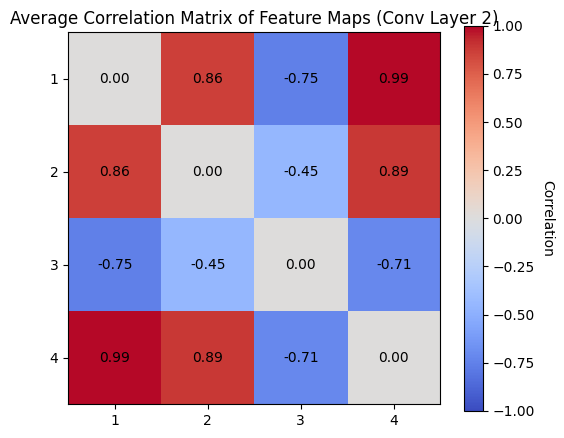

In [ ]:
# compute the average correlation between the feature maps of the second convolutional layer for all the images
model.eval()
with torch.no_grad():
    correlation_matrices = []
    for i in range(len(images)):
        sample_image = images[i].unsqueeze(0) # add batch dimension
        feature_maps = model.encoder[0:5](sample_image) # get the output of the second convolutional layer
        correlation_matrix = np.zeros((feature_maps.shape[1], feature_maps.shape[1]))
        for j in range(feature_maps.shape[1]):
            for k in range(j+1, feature_maps.shape[1]):
                fm1 = feature_maps[0, j].cpu().numpy().flatten()
                fm2 = feature_maps[0, k].cpu().numpy().flatten()
                correlation = np.corrcoef(fm1, fm2)[0, 1]
                correlation_matrix[j, k] = correlation
                correlation_matrix[k, j] = correlation
        correlation_matrices.append(correlation_matrix)

    average_correlation_matrix = np.mean(correlation_matrices, axis=0)

    
# plot the average correlation matrix with the values of the correlations in each cell
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(average_correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Average Correlation Matrix of Feature Maps (Conv Layer 2)')
# add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Correlation', rotation=-90, va="bottom")
# add text annotations
for i in range(average_correlation_matrix.shape[0]):
    for j in range(average_correlation_matrix.shape[1]):
        text = ax.text(j, i, f'{average_correlation_matrix[i, j]:.2f}', ha='center', va='center', color='black')
# increase by 1 the x and y ticks to match the channel numbers (starting from 1 instead of 0)
ax.set_xticks(np.arange(average_correlation_matrix.shape[0]))
ax.set_yticks(np.arange(average_correlation_matrix.shape[0]))
ax.set_xticklabels(np.arange(1, average_correlation_matrix.shape[0]+1))
ax.set_yticklabels(np.arange(1, average_correlation_matrix.shape[0]+1))
plt.show()

# feature maps 1, 2 and 4 are highly correlated with each other in the second convolutional layer, 
# which means that they are learning similar features. This could be a sign of redundancy in the model, 
# and we could try to reduce the number of filters in the second convolutional layer to see if it improves 
# the performance of the model.